In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

In [4]:


# Was broken: 'YYDPETGRWY',
import pickle


proteins = ['chignolin', 'YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY', 'YYDPETGTWG', 'YYDPETGTWQ', 'YYNPETGTWY', 'YYEPETGTWY', 'YYDPETGTWR', 'YYCPETGTWY', 'YYDPETGVWY', 'YYDPETGYWY', 'YYDPETGTWV', 'YYDPETGRWY']

thresholds = np.arange(0.2, 0.50, 0.04)
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]

    for i in range(4000, 4200):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

        try:
            df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue

        passed = set()
        for idx, row in df.iterrows():
            rmsd = row["rmsd"]
            time = row["time"]
            acc = row["metad.acc"]
            predicted = time * acc

            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break



Missing: ../data/YYDPETGTWV/output/run_4145/HLDA_COLVAR_4145
Missing: ../data/YYDPETGTWV/output/run_4147/HLDA_COLVAR_4147
Missing: ../data/YYDPETGTWV/output/run_4150/HLDA_COLVAR_4150
Missing: ../data/YYDPETGTWV/output/run_4157/HLDA_COLVAR_4157


In [ ]:
import pickle

with open("../data/mfpt.pkl", "wb") as f:
    pickle.dump(all_mfpt, f)

In [ ]:

mutation_map = {
    "YYAPETGTWY": "D2A",
    "YYCPETGTWY": "D2C",
    "YYMPETGTWY": "D2M",
    "YYNPETGTWY": "D2N",
    "YYRPETGTWY": "D2R",
    "YYEPETGTWY": "D2E",
    "YYDPETGTWE": "Y9E",
    "YYDPETGTWG": "Y9G",
    "YYDPETGTWQ": "Y9Q",
    "YYDPETGTWR": "Y9R",
    "YYDPETGTWV": "Y9V",
    "YYDPETGTWA": "Y9A",
    "YYDPETGVWY": "T7V",
    "YYDPETGQWY": "T7Q",
    "YYDPETGRWY": "T7R",
    "YYDPETGYWY": "T7Y",
    "chignolin": "Wildtype"
}


groupByResidue = {
    2: ['D2A', 'D2C', 'D2M', 'D2N', 'D2R', 'D2E'], 
    7: ['T7V', 'T7Q', 'T7R', 'T7Y'], 
    9: ['Y9E', 'Y9G', 'Y9Q', 'Y9R', 'Y9V', 'Y9A']
}

groupByProperty = {
    "RHKDE": ["D2R", "D2E", "Y9E", "Y9R", "T7R"],
    "STNQ": ["D2N", "Y9Q", "T7Q"],
    "CUGP": ["D2C", "Y9G"],
    "AVILMFYW": ["D2A", "D2M", "Y9A", "Y9V", "T7V", "T7Y"],
}


In [33]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np


with open("../data/mfpt.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
    
estimator = STiMetaD(minSampleSize=5)
thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
wt_eigenvalue = data.loc['Wildtype', 'eigenvalue']

def collect_df(th: float, sample_size: int):
    rows = []
    # chignolin mean MFPT (for the horiz line)
    chig_sorted = np.array(all_mfpt['chignolin'][th])[:sample_size]
    chig_mfpt = estimator.estimateMFPT(chig_sorted)

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.array(all_mfpt[long_name][th])[:sample_size]
        mfpt = estimator.estimateMFPT(s)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.2f} us")
        # x = eigenvalue difference; y = log MFPT in seconds (assuming your 1e6 factor is us->s)
        x = wt_eigenvalue - data.loc[short, "eigenvalue"]
        y = np.log(mfpt / 1e6)

        rows.append({
            "long": long_name,
            "short": short,
            "x": x,
            "y": y,
            "residue_idx": short_to_residue.get(short),        # 2/7/9 or None
            "property_grp": short_to_property.get(short),      # "RHKDE"/... or None
        })

    df = pd.DataFrame(rows)
    return df, chig_mfpt

def color_map(keys):
    # stable color cycle
    base = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
    return {k: next(base) for k in keys}

sample_size = 200
th = thresholds[4]

df, chig_mfpt = collect_df(th, sample_size)

# quick correlations
pearson, _ = stats.pearsonr(df["x"], df["y"])
spearman, _ = stats.spearmanr(df["x"], df["y"])

chignolin (Wildtype): 18.20 us
YYDPETGTWE (Y9E): 1.60 us
YYRPETGTWY (D2R): 31.12 us
YYAPETGTWY (D2A): 23.98 us
YYDPETGQWY (T7Q): 83.55 us
YYDPETGTWG (Y9G): 1.13 us
YYDPETGTWQ (Y9Q): 2.60 us
YYNPETGTWY (D2N): 1.30 us
YYEPETGTWY (D2E): 48.75 us
YYDPETGTWR (Y9R): 20.42 us
YYCPETGTWY (D2C): 43.08 us
YYDPETGVWY (T7V): 37.18 us
YYDPETGYWY (T7Y): 19.44 us
YYDPETGTWV (Y9V): 0.98 us
YYDPETGRWY (T7R): 556.98 us


/rg/mendels_prj/alexander.z/protein-toolkit/src/STiMetaD.py:66: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / data.loc[data.R2 == data.R2.max()].prediction)


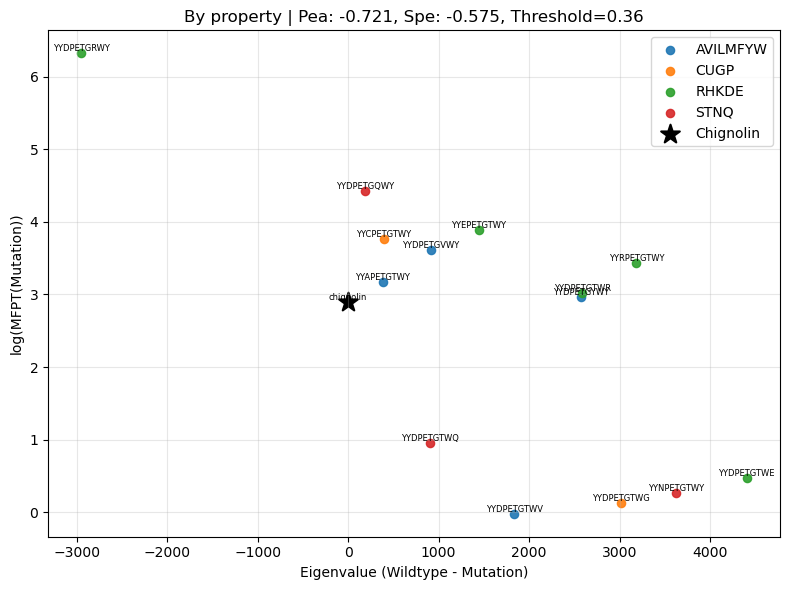

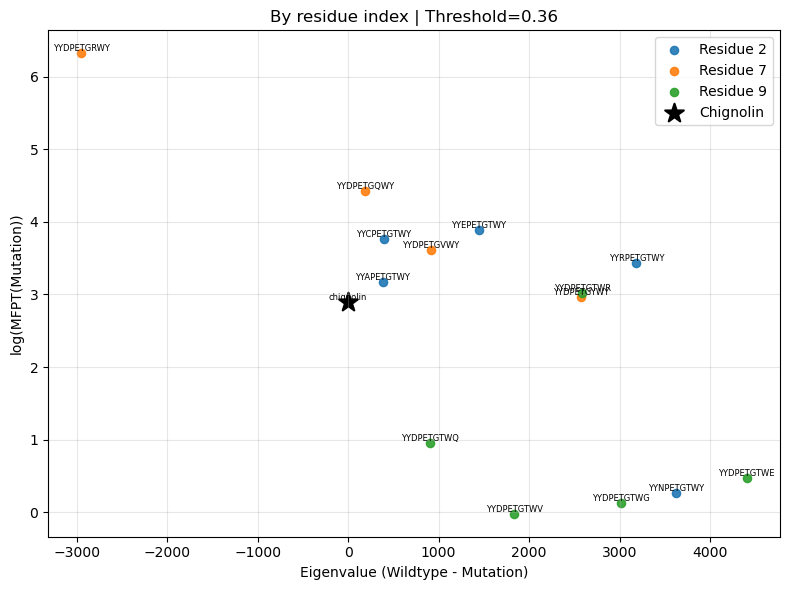


Property-group means:
                        x         y
property_grp                       
AVILMFYW      1425.750000  2.434638
CUGP          1705.000000  1.942496
RHKDE         1733.800000  3.426570
STNQ          1570.666667  1.881179

Residue-index means:
                  x         y
residue_idx                  
2.0          1805.6  2.905699
7.0           180.5  4.332795
9.0          2548.8  0.908051


In [34]:
prop_keys = sorted([k for k in df["property_grp"].dropna().unique()])
prop_colors = color_map(prop_keys)

plt.figure(figsize=(8, 6))
for k in prop_keys:
    sub = df[df["property_grp"] == k]
    plt.scatter(sub["x"], sub["y"], label=k, alpha=0.9, s=35, c=prop_colors[k])

for _, r in df.iterrows():
    plt.text(r["x"], r["y"] + 0.06, r["long"], fontsize=6, ha='center', va='center')

chig_row = df[df["short"] == "Wildtype"]
if not chig_row.empty:
    chig_prop = chig_row.iloc[0]["property_grp"]
    chig_color = prop_colors.get(chig_prop, "black")
    plt.scatter(chig_row["x"], chig_row["y"], s=200, marker='*', c=chig_color,
                edgecolors='k', linewidths=1.5, label="Chignolin")

prop_means = df.dropna(subset=["property_grp"]).groupby("property_grp")[["x", "y"]].mean()
# for k in prop_means.index:
    # plt.scatter(prop_means.loc[k, "x"], prop_means.loc[k, "y"], s=180,
    #             facecolors=prop_colors[k], edgecolors='k', linewidths=1.5)

plt.xlabel('Eigenvalue (Wildtype - Mutation)')
plt.ylabel('log(MFPT(Mutation))')
plt.title(f"By property | Pea: {pearson:.3g}, Spe: {spearman:.3g}, Threshold={th:.3g}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

res_keys = sorted([int(k) for k in df["residue_idx"].dropna().unique()])
res_colors = color_map(res_keys)

plt.figure(figsize=(8, 6))
for k in res_keys:
    sub = df[df["residue_idx"] == k]
    plt.scatter(sub["x"], sub["y"], label=f"Residue {k}", alpha=0.9, s=35, c=res_colors[k])

for _, r in df.iterrows():
    plt.text(r["x"], r["y"] + 0.06, r["long"], fontsize=6, ha='center', va='center')

if not chig_row.empty:
    chig_res = chig_row.iloc[0]["residue_idx"]
    chig_color = res_colors.get(chig_res, "black")
    plt.scatter(chig_row["x"], chig_row["y"], s=200, marker='*', c=chig_color,
                edgecolors='k', linewidths=1.5, label="Chignolin")

res_means = df.dropna(subset=["residue_idx"]).groupby("residue_idx")[["x", "y"]].mean()
# for k in res_means.index:
    # plt.scatter(res_means.loc[k, "x"], res_means.loc[k, "y"], s=180,
    #             facecolors=res_colors[k], edgecolors='k', linewidths=1.5, )

plt.xlabel('Eigenvalue (Wildtype - Mutation)')
plt.ylabel('log(MFPT(Mutation))')
plt.title(f"By residue index | Threshold={th:.3g}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nProperty-group means:")
print(prop_means.sort_index())
print("\nResidue-index means:")
print(res_means.sort_index())


/rg/mendels_prj/alexander.z/protein-toolkit/src/STiMetaD.py:20: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-t / a)


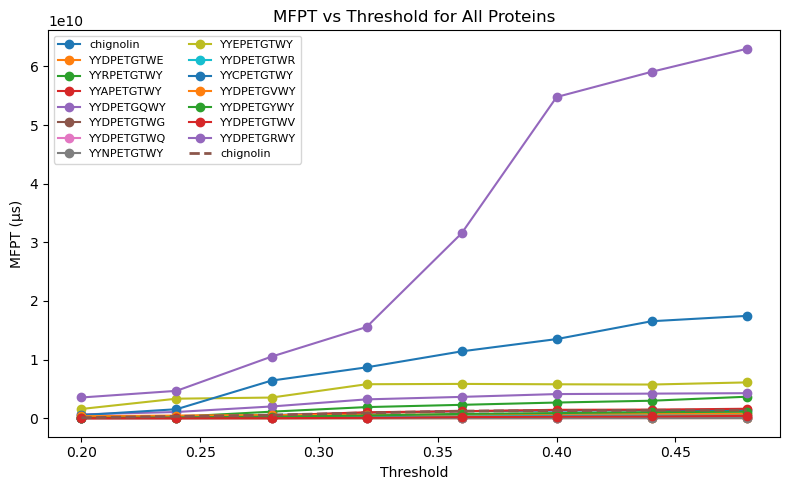

In [35]:
def plot_all_mfpt(all_mfpt, proteins, thresholds, sample_size):
    # Collect MFPT (µs) for every protein across thresholds
    series = {p: [] for p in proteins}
    chig = []

    for th in thresholds:
        # Optional: chignolin baseline per-threshold if available
        if 'chignolin' in all_mfpt and th in all_mfpt['chignolin']:
            s = np.array(all_mfpt['chignolin'][th])[:sample_size]
            chig_mfpt, _ = estimator.iMetaDMFPT(s, KStest=True)
            chig.append(chig_mfpt)
        else:
            chig.append(np.nan)

        for p in proteins:
            s = np.array(all_mfpt[p][th])[:sample_size]
            mfpt, _ = estimator.iMetaDMFPT(s, KStest=True)  # returns µs
            series[p].append(mfpt)

    # Plot
    plt.figure(figsize=(8, 5))
    for p, ys in series.items():
        plt.plot(thresholds, ys, marker='o', label=p)
    # Chignolin reference (if present)
    if not np.all(np.isnan(chig)):
        plt.plot(thresholds, chig, linestyle='--', linewidth=2, label='chignolin')

    plt.xlabel('Threshold')
    plt.ylabel('MFPT (µs)')
    # plt.yscale('log')  # MFPTs often span orders of magnitude
    plt.title('MFPT vs Threshold for All Proteins')
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_all_mfpt(all_mfpt, proteins, thresholds, sample_size=200)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def fit_exp_ecdf(samples, ax=None):
    x = np.asarray(samples, float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    x.sort()
    n = x.size
    tau = x.mean()
    ecdf = np.arange(1, n + 1) / n
    th = stats.expon.cdf(x, scale=tau)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label="Exponential CDF")
    ax.set_xlabel("t")
    ax.set_ylabel("CDF")
    ax.legend()
    plt.show()
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, D, p, ax

      name  n          tau     ks_p     ks_D
YYDPETGTWV 20 1.426472e+04 0.923593 0.115762
 chignolin 20 3.197520e+05 0.911123 0.118407
YYCPETGTWY 20 1.418216e+06 0.871570 0.125738
YYAPETGTWY 20 1.935589e+05 0.786429 0.138808
YYDPETGQWY 20 1.536480e+06 0.776115 0.140262
YYDPETGVWY 20 1.218256e+06 0.745282 0.144516
YYNPETGTWY 20 5.454013e+04 0.720792 0.147822
YYDPETGTWE 20 1.931025e+04 0.651621 0.156967
YYRPETGTWY 20 4.646570e+05 0.520912 0.174425
YYDPETGYWY 20 3.948242e+05 0.449960 0.184563
YYDPETGTWG 20 1.877027e+04 0.383090 0.194931
YYDPETGTWR 20 8.862147e+04 0.358138 0.199076
YYDPETGTWQ 20 3.923494e+04 0.357221 0.199232
YYDPETGRWY 20 1.217198e+07 0.249925 0.219722
YYEPETGTWY 20 4.960260e+05 0.160390 0.242610


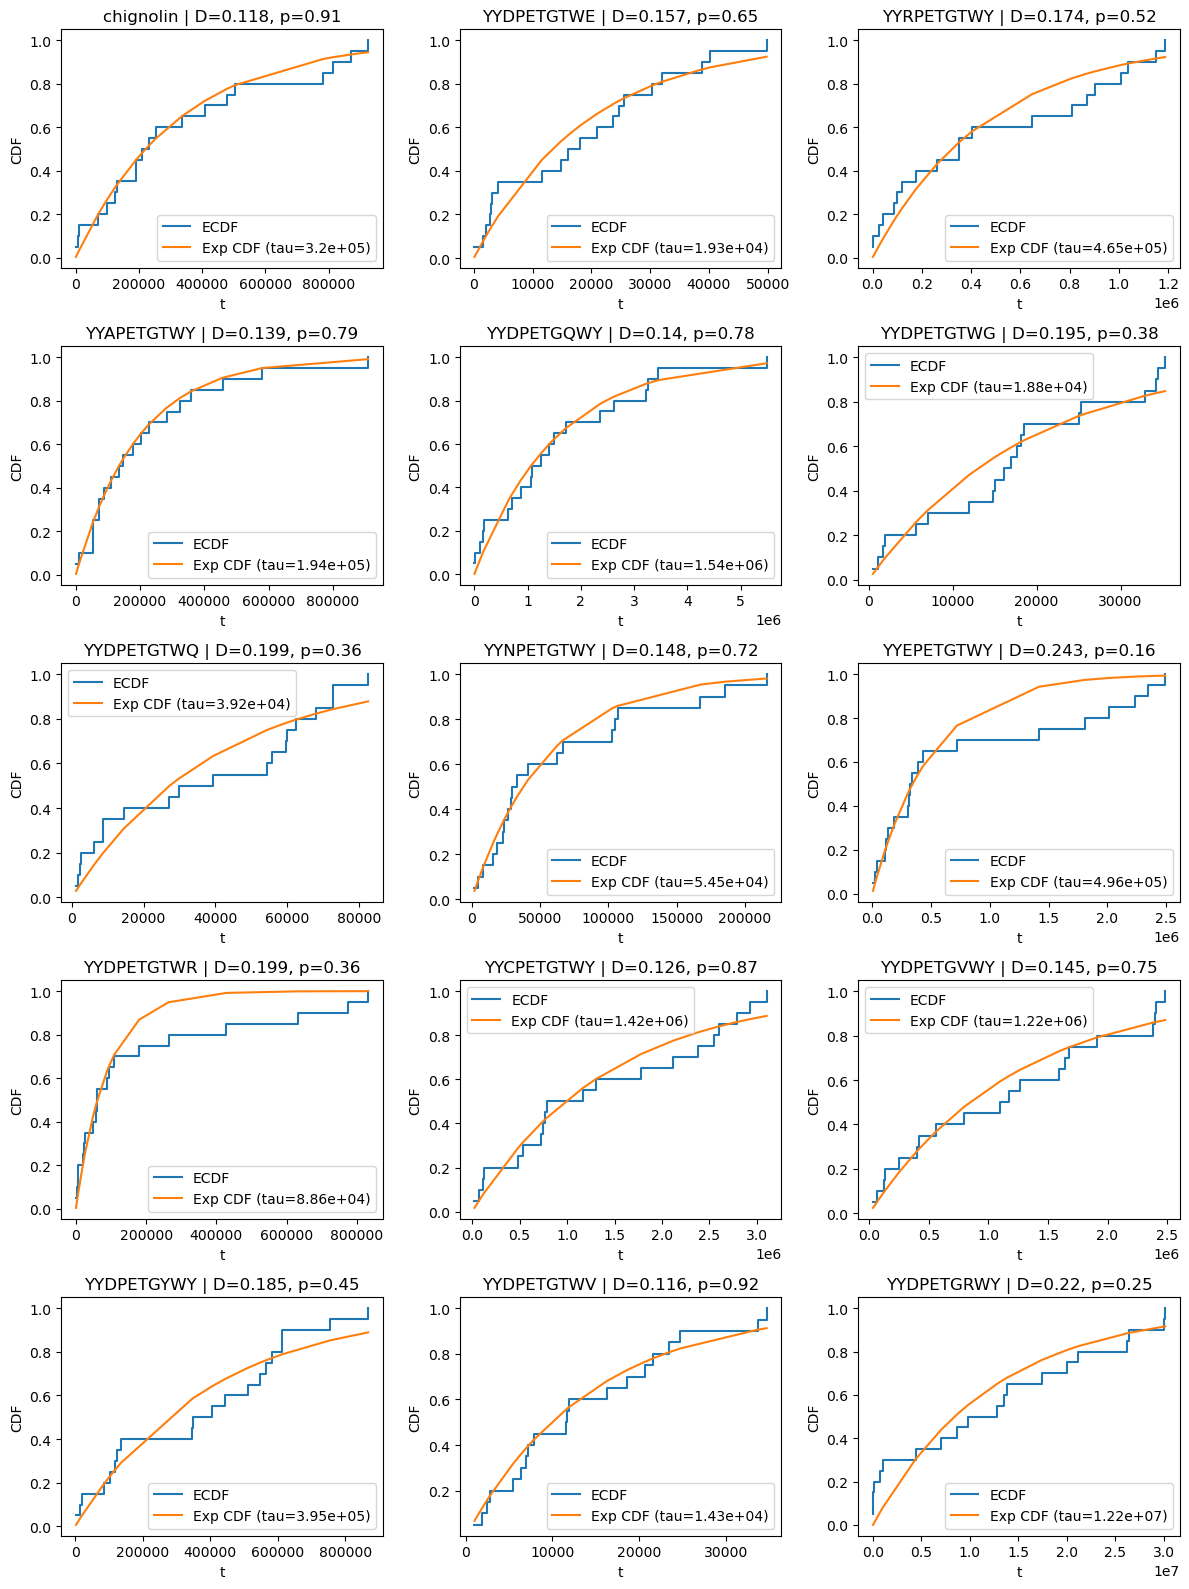

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import math

def fit_exp_ks(samples):
    x = np.asarray(samples, float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    x.sort()
    if x.size == 0:
        raise ValueError("empty samples")
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D

def fit_exp_ecdf(samples, ax=None):
    x = np.asarray(samples, float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    x.sort()
    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.asarray(all_mfpt[name][th], float)
        s = s[np.isfinite(s)]
        if s.size == 0:
            continue
        s.sort()
        s = s[:min(k, s.size)]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k, ncols=3):
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        s = np.asarray(all_mfpt[name][th], float)
        s = s[np.isfinite(s)]
        s.sort()
        s = s[:min(k, s.size)]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{name} | " + axes[r, c].get_title())
    for j in range(i + 1, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")
    fig.tight_layout()
    return fig

th = thresholds[1]
names = list(proteins)
res = ks_table_fastest_k(all_mfpt, names, th, k=20)
print(res.to_string(index=False))
fig = plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k=20, ncols=3)
plt.show()
